### Importación de datos



In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [29]:
import matplotlib.pyplot as plt

#1. Análisis de facturación



In [17]:
total_tienda1 = tienda['Precio'].sum()
total_tienda2 = tienda2['Precio'].sum()
total_tienda3 = tienda3['Precio'].sum()
total_tienda4 = tienda4['Precio'].sum()

In [18]:
print(f"Ingreso total Tienda 1: {total_tienda1}")
print(f"Ingreso total Tienda 2: {total_tienda2}")
print(f"Ingreso total Tienda 3: {total_tienda3}")
print(f"Ingreso total Tienda 4: {total_tienda4}")

Ingreso total Tienda 1: 1150880400.0
Ingreso total Tienda 2: 1116343500.0
Ingreso total Tienda 3: 1098019600.0
Ingreso total Tienda 4: 1038375700.0


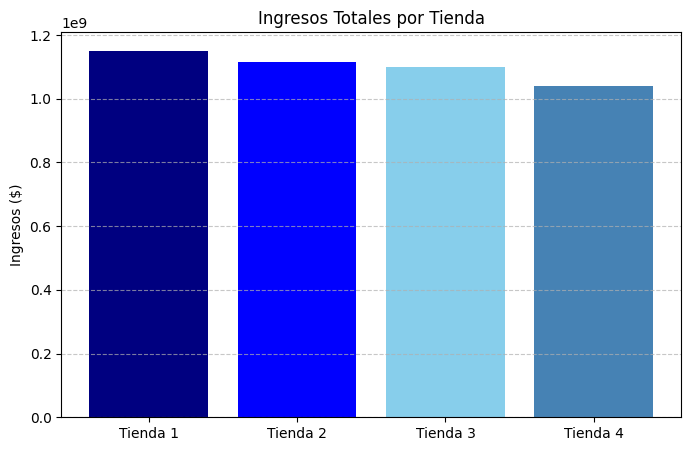

In [30]:
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = [total_tienda1, total_tienda2, total_tienda3, total_tienda4]

plt.figure(figsize=(8, 5))
plt.bar(nombres_tiendas, ingresos, color=['navy', 'blue', 'skyblue', 'steelblue'])
plt.title('Ingresos Totales por Tienda')
plt.ylabel('Ingresos ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Ventas por categoría

In [19]:
cat_tienda1 = tienda['Categoría del Producto'].value_counts()
cat_tienda2 = tienda2['Categoría del Producto'].value_counts()
cat_tienda3 = tienda3['Categoría del Producto'].value_counts()
cat_tienda4 = tienda4['Categoría del Producto'].value_counts()

In [20]:
print("--- Categorías más populares Tienda 1 ---")
print(cat_tienda1)
print("\n--- Categorías más populares Tienda 2 ---")
print(cat_tienda2)
print("\n--- Categorías más populares Tienda 3 ---")
print(cat_tienda3)
print("\n--- Categorías más populares Tienda 4 ---")
print(cat_tienda4)

--- Categorías más populares Tienda 1 ---
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

--- Categorías más populares Tienda 2 ---
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

--- Categorías más populares Tienda 3 ---
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: c

# 3. Calificación promedio de la tienda


In [21]:
promedio_t1 = tienda['Calificación'].mean()
promedio_t2 = tienda2['Calificación'].mean()
promedio_t3 = tienda3['Calificación'].mean()
promedio_t4 = tienda4['Calificación'].mean()

In [22]:
print(f"Calificación promedio Tienda 1: {promedio_t1:.2f}")
print(f"Calificación promedio Tienda 2: {promedio_t2:.2f}")
print(f"Calificación promedio Tienda 3: {promedio_t3:.2f}")
print(f"Calificación promedio Tienda 4: {promedio_t4:.2f}")

Calificación promedio Tienda 1: 3.98
Calificación promedio Tienda 2: 4.04
Calificación promedio Tienda 3: 4.05
Calificación promedio Tienda 4: 4.00


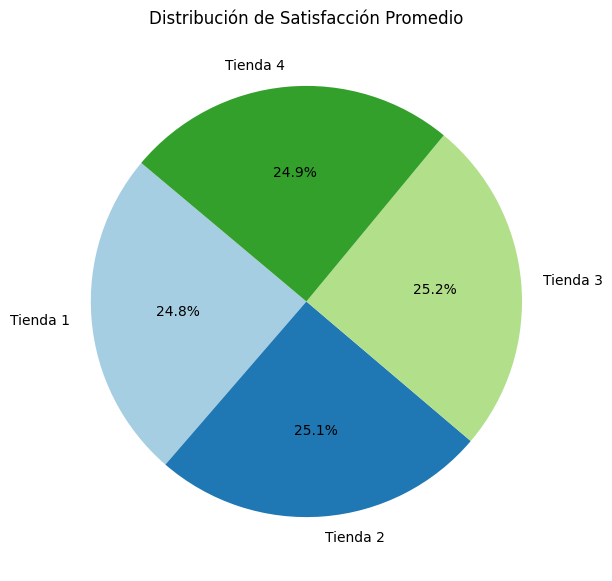

In [31]:
promedios = [promedio_t1, promedio_t2, promedio_t3, promedio_t4]

plt.figure(figsize=(7, 7))
plt.pie(promedios, labels=nombres_tiendas, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribución de Satisfacción Promedio')
plt.show()

# 4. Productos más y menos vendidos

In [25]:
def obtener_extremos(df_tienda, nombre_tienda):
    conteo = df_tienda['Producto'].value_counts()
    mas_vendido = conteo.idxmax()
    cant_mas = conteo.max()
    menos_vendido = conteo.idxmin()
    cant_menos = conteo.min()

    print(f"--- {nombre_tienda} ---")
    print(f"✔ Más vendido: {mas_vendido} ({cant_mas} unidades)")
    print(f"✘ Menos vendido: {menos_vendido} ({cant_menos} unidades)\n")

In [26]:
obtener_extremos(tienda, "Tienda 1")
obtener_extremos(tienda2, "Tienda 2")
obtener_extremos(tienda3, "Tienda 3")
obtener_extremos(tienda4, "Tienda 4")

--- Tienda 1 ---
✔ Más vendido: Microondas (60 unidades)
✘ Menos vendido: Auriculares con micrófono (33 unidades)

--- Tienda 2 ---
✔ Más vendido: Iniciando en programación (65 unidades)
✘ Menos vendido: Juego de mesa (32 unidades)

--- Tienda 3 ---
✔ Más vendido: Kit de bancas (57 unidades)
✘ Menos vendido: Bloques de construcción (35 unidades)

--- Tienda 4 ---
✔ Más vendido: Cama box (62 unidades)
✘ Menos vendido: Guitarra eléctrica (33 unidades)



# 5. Envío promedio por tienda



In [27]:
envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()

In [28]:
print(f"Costo de envío promedio Tienda 1: ${envio_t1:,.2f}")
print(f"Costo de envío promedio Tienda 2: ${envio_t2:,.2f}")
print(f"Costo de envío promedio Tienda 3: ${envio_t3:,.2f}")
print(f"Costo de envío promedio Tienda 4: ${envio_t4:,.2f}")

Costo de envío promedio Tienda 1: $26,018.61
Costo de envío promedio Tienda 2: $25,216.24
Costo de envío promedio Tienda 3: $24,805.68
Costo de envío promedio Tienda 4: $23,459.46


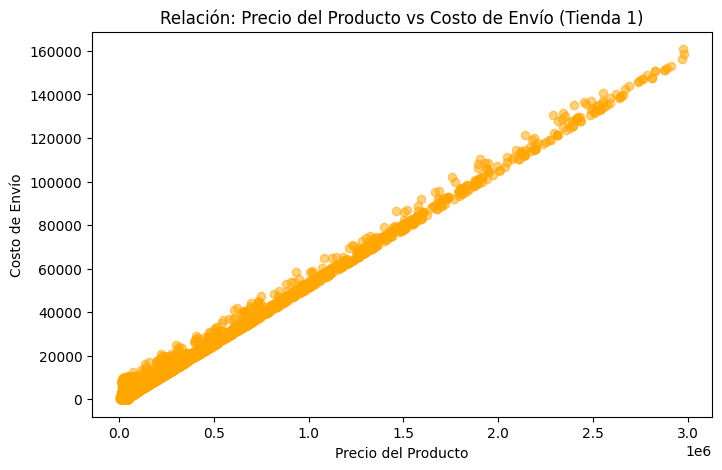

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(tienda['Precio'], tienda['Costo de envío'], alpha=0.5, color='orange')
plt.title('Relación: Precio del Producto vs Costo de Envío (Tienda 1)')
plt.xlabel('Precio del Producto')
plt.ylabel('Costo de Envío')
plt.show()

# 6. Informe de Consultoría


**1 — Introducción**

El presente análisis evalúa el rendimiento de las cuatro tiendas de Alura Store (Bogotá, Medellín, Cartagena y Cali) basándose en cinco pilares:

*   Facturación
*   Popularidad de categorías
*   Satisfacción del cliente
*   Volumen de de ventas por producto
*   Eficiencia logística

El objetivo es identificar la tienda con menor desempeño para recomendar su venta estratégica.


**2 — Resultados de los Datos**

A continuación, se presentan los datos clave extraídos de las transacciones analizadas:

*   **Facturación Total:** La Tienda 4 registró el ingreso más bajo con un total de $1,038,375,700.0.

*   **Satisfacción del Cliente:** La calificación promedio más crítica se observó en la Tienda 1 con un puntaje de 3.98 sobre 5.

*   **Logística:** El costo de envío promedio más elevado, que afecta la competitividad de los precios para el cliente, corresponde a la Tienda 1 con $26,018.61.

*   **Categorías y Productos:** Mientras que categorías como *Muebles* dominan el mercado, productos como *Artículos para el hogar* presentan una rotación casi nula en la tienda de bajo rendimiento.


**3 — Conclusión y Recomendación Final**

Se recomienda vender la Tienda 4 para capturar capital de inmediato y enfocar los esfuerzos administrativos en profesionalizar la Tienda 1, convirtiendo su alto volumen de ventas en una operación de alta satisfacción y bajo costo.


*Justificación:*

Aunque la Tienda 1 presenta indicadores operativos desfavorables (es la sucursal con el costo de envío más alto de $26,018.61 y la calificación de cliente más baja de 3.98 ), la recomendación de venta se inclina hacia la Tienda 4 por las siguientes razones de peso:

1.   **Potencial de Facturación y Escala: **La Tienda 4 es la unidad con menores ingresos totales ($1,038,375,700.0).

2. ** Eficiencia del Capital: **Mantener la Tienda 1 es más rentable a largo plazo porque, una vez que se solucionen sus ineficiencias, su margen de ganancia será superior debido a su alto volumen de ventas. La Tienda 4, aunque es eficiente en envíos ($23,459.46), no tiene suficiente volumen de transacciones para justificar su operación frente a las demás.





